<a href="https://colab.research.google.com/github/zilongcheng582-cyber/atayal-nlp-summer/blob/main/notebooks/04_mfcc_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 MFCC Audio Feature Extraction — Atayal (Zeyuan Dialect)
This notebook extracts MFCC features from aligned Atayal audio samples
and visualizes the acoustic properties of the speech data.
## MFCC Analysis Summary
- Extracted 13 MFCC coefficients from 4 audio samples
- Short sentences: ~3 seconds each
- Long dialogue sample: 41.1 seconds
- All audio files are aligned with Atayal text transcriptions
- MFCC features can serve as input for future speech recognition experiments


In [1]:
!pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

print("库安装完成！")

库安装完成！


In [2]:
import urllib.request

# 从 GitHub 下载示例音频
base_url = "https://raw.githubusercontent.com/zilongcheng582-cyber/atayal-nlp-summer/main/audio/samples/"

files = ["1-A.wav", "1-B-1.wav", "1-B-2.wav","10-B-4.wav"]

for f in files:
    urllib.request.urlretrieve(base_url + f, f)
    print(f"下载完成：{f}")

下载完成：1-A.wav
下载完成：1-B-1.wav
下载完成：1-B-2.wav
下载完成：10-B-4.wav


音频长度：3.75 秒
采样率：22050 Hz
MFCC 形状：(13, 162)


/tmp/ipykernel_1043/1586426244.py:18: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


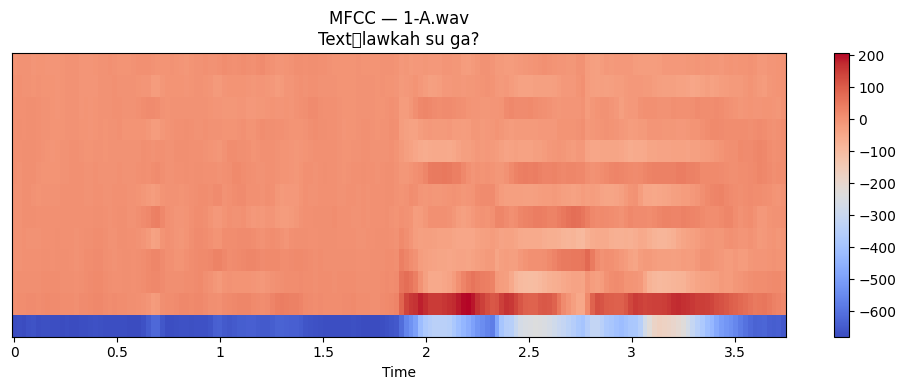

In [4]:
# 提取并可视化第一个音频的 MFCC
audio_file = "1-A.wav"

# 加载音频
y, sr = librosa.load(audio_file)
print(f"音频长度：{len(y)/sr:.2f} 秒")
print(f"采样率：{sr} Hz")

# 提取 MFCC
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCC 形状：{mfcc.shape}")

# 可视化
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=sr)
plt.colorbar()
plt.title(f"MFCC — 1-A.wav\nText：lawkah su ga?")
plt.tight_layout()
plt.show()

长音频长度：41.13 秒


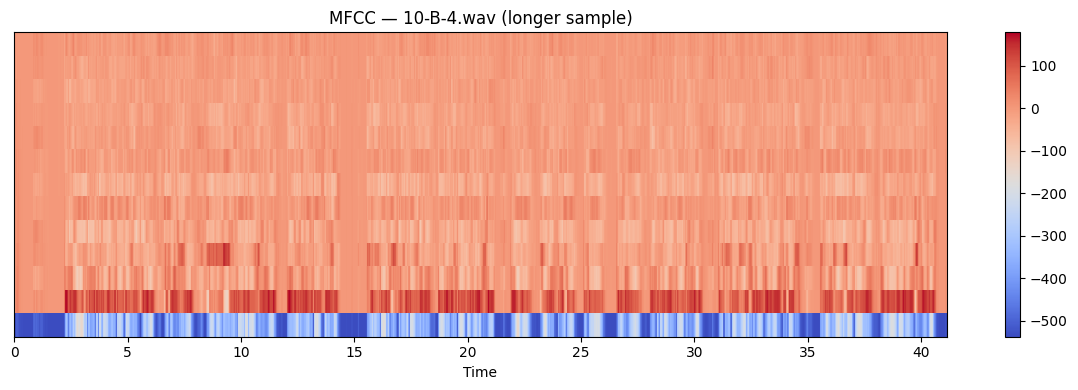

In [5]:
# 对比长音频
y_long, sr_long = librosa.load("10-B-4.wav")
print(f"长音频长度：{len(y_long)/sr_long:.2f} 秒")

mfcc_long = librosa.feature.mfcc(y=y_long, sr=sr_long, n_mfcc=13)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_long, x_axis='time', sr=sr_long)
plt.colorbar()
plt.title("MFCC — 10-B-4.wav (longer sample)")
plt.tight_layout()
plt.show()


In [6]:
# 展示文本-音频对齐关系
alignment = {
    "1-A.wav":   "lawkah su ga?",
    "1-B-1.wav": "psba biru, lawkah su ga?",
    "1-B-2.wav": "lawkah kung, mhuway su, isu ga?",
    "10-B-4.wav": "mkura sku ptna’un ta tayux kwara ss’uli ga, siki syun ta balay inlungan ru llungun ta krryax, ini ta kcikuy mtayux ru mhmut mita ana m’ima. mwana kyan utux sa blay, mhuway ru ptna’un na inlungan, nki thuyay msblay kwara utux sali, inlhuyan syakay ru kwara babaw cinbwanan."
}

print("文本-音频对齐示例：")
print("-" * 40)
for audio, text in alignment.items():
    y, sr = librosa.load(audio)
    duration = len(y) / sr
    print(f"{audio:20s} | {duration:.1f}s | {text}")

文本-音频对齐示例：
----------------------------------------
1-A.wav              | 3.8s | lawkah su ga?
1-B-1.wav            | 3.0s | psba biru, lawkah su ga?
1-B-2.wav            | 3.3s | lawkah kung, mhuway su, isu ga?
10-B-4.wav           | 41.1s | mkura sku ptna’un ta tayux kwara ss’uli ga, siki syun ta balay inlungan ru llungun ta krryax, ini ta kcikuy mtayux ru mhmut mita ana m’ima. mwana kyan utux sa blay, mhuway ru ptna’un na inlungan, nki thuyay msblay kwara utux sali, inlhuyan syakay ru kwara babaw cinbwanan.
